# 04 · Kernel UTAM y compuerta numérica de primer paso — Bogotá 2023

**Objetivo.** Convertir la red UTAM aceptada por la Compuerta 4 en una cadena de Markov reproducible y verificar que los tiempos de primera llegada pueden calcularse de forma estable.

Este notebook es una **prueba numérica previa** al análisis sustantivo. Los conjuntos objetivo se definen por flujo entrante (5 %, 10 % y 20 % de las UTAM) únicamente para probar el algoritmo; **no representan todavía trabajo, educación, salud ni otros servicios**.

Los tiempos se expresan en **número de transiciones**, no en minutos. Una interpretación temporal requerirá duraciones o un modelo semi-Markov posterior.


In [1]:
%pip -q install pandas pyarrow numpy scipy networkx matplotlib seaborn


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import shutil

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
OUT = ROOT / "outputs/bogota_em2023/gate5"
DRIVE_BASE = Path(
    "/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023"
)
OUT.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 202309
TARGET_FRACTIONS = (0.05, 0.10, 0.20)
MC_REPLICATES = 3000
MC_ORIGINS = 12
MAX_MC_STEPS = 2000

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

override = os.environ.get("GATE4_DIR_OVERRIDE")
GATE4_DIR = Path(override) if override else DRIVE_BASE / "results/gate4"
EDGE_PATH = GATE4_DIR / "transition_edges_utam.parquet"
GATE4_PATH = GATE4_DIR / "gate_4.json"

missing = [str(path) for path in (EDGE_PATH, GATE4_PATH) if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Faltan artefactos de la Compuerta 4 en Drive: " + ", ".join(missing)
    )

gate4 = json.loads(GATE4_PATH.read_text(encoding="utf-8"))
gate4_status = gate4.get("gate", gate4)
if not bool(gate4_status.get("gate_4_passed", False)):
    raise RuntimeError("La Compuerta 4 no fue aprobada; no se construirá el kernel.")
if str(gate4_status.get(
    "recommended_resolution", gate4.get("recommended_resolution", "")
)).upper() != "UTAM":
    raise RuntimeError("La resolución recomendada por la Compuerta 4 no es UTAM.")

print("Entrada:", EDGE_PATH)
print("Salida:", OUT)


Mounted at /content/drive
Entrada: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate4/transition_edges_utam.parquet
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate5


## 1. Auditoría del artefacto de entrada

Se eliminan etiquetas no espaciales como `No aplica`. `UTAM063` se conserva en la cadena porque tiene transiciones observadas, pero deberá excluirse de mapas si continúa sin geometría oficial. Su peso se cuantifica explícitamente.


In [3]:
edges_raw = pd.read_parquet(EDGE_PATH)
required = {
    "utam_ori", "utam_des", "sampled_trips", "weighted_trips",
    "effective_sample_size", "transition_probability",
}
missing_columns = sorted(required - set(edges_raw.columns))
if missing_columns:
    raise KeyError(f"Columnas ausentes: {missing_columns}")

edges = edges_raw.copy()
invalid = {"", "NAN", "NONE", "NULL", "<NA>", "NO APLICA", "N/A", "NA"}
for column in ("utam_ori", "utam_des"):
    clean = edges[column].astype("string").str.strip().str.upper()
    edges[column] = clean.mask(clean.isin(invalid))

valid_mask = edges[["utam_ori", "utam_des"]].notna().all(axis=1)
excluded = edges.loc[~valid_mask].copy()
edges = edges.loc[valid_mask].copy()

incident_063 = edges["utam_ori"].eq("UTAM063") | edges["utam_des"].eq("UTAM063")
input_audit = {
    "raw_edge_rows": int(len(edges_raw)),
    "valid_edge_rows": int(len(edges)),
    "excluded_nonspatial_edge_rows": int(len(excluded)),
    "excluded_nonspatial_weight_share": float(
        excluded["weighted_trips"].sum() / edges_raw["weighted_trips"].sum()
    ),
    "utam063_incident_edge_rows": int(incident_063.sum()),
    "utam063_incident_sampled_trips": int(
        edges.loc[incident_063, "sampled_trips"].sum()
    ),
    "utam063_incident_weight_share": float(
        edges.loc[incident_063, "weighted_trips"].sum()
        / edges["weighted_trips"].sum()
    ),
}
pd.Series(input_audit, name="value").to_csv(OUT / "input_audit.csv")
display(pd.Series(input_audit, name="value"))


,value
raw_edge_rows,12408.000000
valid_edge_rows,12408.000000
excluded_nonspatial_edge_rows,0.000000
excluded_nonspatial_weight_share,0.000000
utam063_incident_edge_rows,2.000000
utam063_incident_sampled_trips,2.000000
utam063_incident_weight_share,0.000011


## 2. Matriz de transición UTAM

Sea (W=(w_{ij})) la matriz de viajes expandidos. El kernel se define por

\[
P_{ij}=rac{w_{ij}}{\sum_k w_{ik}}.
\]

La cadena se evalúa por estocasticidad, conectividad fuerte, aperiodicidad, convergencia estacionaria y brecha espectral.


In [4]:
nodes = sorted(set(edges["utam_ori"]) | set(edges["utam_des"]))
node_to_index = {node: index for index, node in enumerate(nodes)}
n_nodes = len(nodes)

W = np.zeros((n_nodes, n_nodes), dtype=float)
N = np.zeros((n_nodes, n_nodes), dtype=float)
for row in edges.itertuples(index=False):
    i = node_to_index[row.utam_ori]
    j = node_to_index[row.utam_des]
    W[i, j] += float(row.weighted_trips)
    N[i, j] += float(row.sampled_trips)

outflow = W.sum(axis=1)
if np.any(outflow <= 0):
    bad = [nodes[i] for i in np.flatnonzero(outflow <= 0)]
    raise RuntimeError(f"Nodos sin flujo saliente: {bad}")

P = W / outflow[:, None]
row_sum_error = float(np.max(np.abs(P.sum(axis=1) - 1.0)))

graph = nx.DiGraph()
graph.add_nodes_from(range(n_nodes))
rows, columns = np.nonzero(P > 0)
graph.add_edges_from(zip(rows.tolist(), columns.tolist()))
irreducible = bool(nx.is_strongly_connected(graph))
aperiodic = bool(nx.is_aperiodic(graph)) if irreducible else False

stationary = np.full(n_nodes, 1.0 / n_nodes)
converged = False
for iteration in range(100_000):
    updated = stationary @ P
    if np.linalg.norm(updated - stationary, ord=1) < 1e-14:
        stationary = updated
        converged = True
        break
    stationary = updated

stationary_residual = float(np.linalg.norm(stationary @ P - stationary, ord=1))
eigenvalues = np.linalg.eigvals(P)
eigenvalue_moduli = np.sort(np.abs(eigenvalues))[::-1]
slem = float(eigenvalue_moduli[1])
spectral_gap = float(1.0 - slem)

chain_diagnostics = {
    "nodes": int(n_nodes),
    "positive_transitions": int((P > 0).sum()),
    "max_row_sum_error": row_sum_error,
    "irreducible": irreducible,
    "aperiodic": aperiodic,
    "stationary_converged": bool(converged),
    "stationary_iterations": int(iteration + 1),
    "stationary_residual_l1": stationary_residual,
    "slem": slem,
    "spectral_gap": spectral_gap,
}

stationary_table = pd.DataFrame({
    "utam": nodes,
    "stationary_probability": stationary,
    "mean_return_steps": 1.0 / stationary,
    "weighted_outflow": outflow,
    "weighted_inflow": W.sum(axis=0),
})
stationary_table.to_csv(OUT / "stationary_distribution.csv", index=False)
pd.Series(chain_diagnostics, name="value").to_csv(OUT / "chain_diagnostics.csv")
display(pd.Series(chain_diagnostics, name="value"))
display(stationary_table.nlargest(10, "stationary_probability"))


,value
nodes,141
positive_transitions,12408
max_row_sum_error,0.0
irreducible,True
aperiodic,True
stationary_converged,True
stationary_iterations,325
stationary_residual_l1,0.0
slem,0.923144
spectral_gap,0.076856


,utam,stationary_probability,mean_return_steps,weighted_outflow,weighted_inflow
83,UTAM085,0.030632,32.645276,492876.3,496079.6
82,UTAM084,0.022666,44.119872,368129.5,367918.5
94,UTAM097,0.021257,47.044385,338477.0,346685.0
96,UTAM099,0.017604,56.804283,283207.5,287435.9
22,UTAM024,0.017356,57.616462,286843.8,284588.1
65,UTAM067,0.016988,58.863779,280060.3,277994.7
69,UTAM071,0.016965,58.945195,279082.4,277971.5
40,UTAM042,0.016330,61.236816,263514.8,265244.3
80,UTAM082,0.015998,62.508840,260505.6,261749.7
44,UTAM046,0.015762,63.442835,256469.7,257418.4


## 3. Conjuntos objetivo técnicos

Para evitar escoger servicios después de observar resultados, esta compuerta usa tres conjuntos predefinidos: el 5 %, 10 % y 20 % de las UTAM con mayor flujo entrante. Estos objetivos sirven únicamente para comprobar estabilidad, condicionamiento y escalamiento del método.


In [5]:
inflow = W.sum(axis=0)
target_sets = {}
target_rows = []
for fraction in TARGET_FRACTIONS:
    number = max(1, int(np.ceil(fraction * n_nodes)))
    target_indices = np.argsort(inflow)[-number:]
    label = f"top_{int(round(100 * fraction)):02d}_inflow"
    target_sets[label] = np.sort(target_indices)
    for rank, index in enumerate(
        target_indices[np.argsort(inflow[target_indices])[::-1]], start=1
    ):
        target_rows.append({
            "target_set": label,
            "target_fraction": float(fraction),
            "rank_within_set": int(rank),
            "utam": nodes[index],
            "weighted_inflow": float(inflow[index]),
        })

technical_targets = pd.DataFrame(target_rows)
technical_targets.to_csv(OUT / "technical_targets.csv", index=False)
display(technical_targets.groupby("target_set").agg(
    target_nodes=("utam", "nunique"),
    minimum_inflow=("weighted_inflow", "min"),
    maximum_inflow=("weighted_inflow", "max"),
))


,target_nodes,minimum_inflow,maximum_inflow
target_set,,,
top_05_inflow,8,265244.3,496079.6
top_10_inflow,15,226291.0,496079.6
top_20_inflow,29,185589.4,496079.6


## 4. Tiempos de primera llegada

Para un conjunto objetivo (A), sea (Q) la submatriz de (P) restringida a estados fuera de (A). El vector de tiempos medios satisface

\[
(I-Q)h=\mathbf{1}.
\]

El segundo momento se obtiene resolviendo

\[
(I-Q)m_2=\mathbf{1}+2Qh.
\]

Además de la media, se calculan desviación y cuantiles agregados de la distribución de primera llegada.


In [6]:
def first_passage_solution(P, target_indices):
    target = np.zeros(P.shape[0], dtype=bool)
    target[target_indices] = True
    transient = np.flatnonzero(~target)
    Q = P[np.ix_(transient, transient)]
    system = np.eye(len(transient)) - Q
    condition_number = float(np.linalg.cond(system))
    mean = np.linalg.solve(system, np.ones(len(transient)))
    second = np.linalg.solve(system, np.ones(len(transient)) + 2 * Q @ mean)
    variance = np.maximum(second - mean**2, 0.0)

    full_mean = np.zeros(P.shape[0])
    full_sd = np.zeros(P.shape[0])
    full_mean[transient] = mean
    full_sd[transient] = np.sqrt(variance)
    return transient, Q, full_mean, full_sd, condition_number


def aggregate_quantiles(Q, initial, probabilities=(0.50, 0.90, 0.95), horizon=1000):
    distribution = initial.copy()
    result = {}
    for step in range(1, horizon + 1):
        distribution = distribution @ Q
        cdf = 1.0 - float(distribution.sum())
        for probability in probabilities:
            if probability not in result and cdf >= probability:
                result[probability] = int(step)
        if len(result) == len(probabilities):
            break
    return result, float(distribution.sum()), int(step)


fpt_rows = []
summary_rows = []
solutions = {}
for label, targets in target_sets.items():
    transient, Q, mean, sd, condition_number = first_passage_solution(P, targets)
    initial = outflow[transient] / outflow[transient].sum()
    quantiles, residual_survival, horizon_used = aggregate_quantiles(Q, initial)

    mixture_mean = float(initial @ mean[transient])
    mixture_second = float(initial @ (sd[transient] ** 2 + mean[transient] ** 2))
    mixture_sd = float(np.sqrt(max(mixture_second - mixture_mean**2, 0.0)))
    solutions[label] = {
        "targets": targets,
        "transient": transient,
        "Q": Q,
        "mean": mean,
        "sd": sd,
    }

    summary_rows.append({
        "target_set": label,
        "target_nodes": int(len(targets)),
        "mean_fpt_steps": mixture_mean,
        "sd_fpt_steps": mixture_sd,
        "median_fpt_steps": int(quantiles.get(0.50, -1)),
        "p90_fpt_steps": int(quantiles.get(0.90, -1)),
        "p95_fpt_steps": int(quantiles.get(0.95, -1)),
        "max_origin_mean_fpt_steps": float(mean.max()),
        "condition_number": condition_number,
        "tail_survival_at_horizon": residual_survival,
        "tail_horizon_steps": horizon_used,
    })
    target_mask = np.zeros(n_nodes, dtype=bool)
    target_mask[targets] = True
    for index, node in enumerate(nodes):
        fpt_rows.append({
            "target_set": label,
            "utam": node,
            "is_target": bool(target_mask[index]),
            "mean_fpt_steps": float(mean[index]),
            "sd_fpt_steps": float(sd[index]),
            "weighted_outflow": float(outflow[index]),
        })

fpt_by_origin = pd.DataFrame(fpt_rows)
fpt_summary = pd.DataFrame(summary_rows)
fpt_by_origin.to_csv(OUT / "fpt_by_origin.csv", index=False)
fpt_summary.to_csv(OUT / "fpt_summary.csv", index=False)
display(fpt_summary)


,target_set,target_nodes,mean_fpt_steps,sd_fpt_steps,median_fpt_steps,p90_fpt_steps,p95_fpt_steps,max_origin_mean_fpt_steps,condition_number,tail_survival_at_horizon,tail_horizon_steps
0,top_05_inflow,8,10.184833,10.457692,7,23,31,23.800774,24.394042,0.046800,31
1,top_10_inflow,15,6.838227,7.159852,5,15,20,20.092619,22.688959,0.049588,20
2,top_20_inflow,29,4.015416,4.707609,3,8,12,17.353674,22.366470,0.041253,12


## 5. Validación Monte Carlo

Se seleccionan las doce UTAM no objetivo con mayor flujo saliente para el conjunto técnico del 10 %. Cada tiempo teórico se contrasta con 3 000 caminatas independientes. La simulación se usa como verificación, no como estimador principal.


In [7]:
def simulate_hitting_times(P, start, targets, replicates, max_steps, rng):
    target_mask = np.zeros(P.shape[0], dtype=bool)
    target_mask[targets] = True
    states = np.full(replicates, start, dtype=int)
    times = np.zeros(replicates, dtype=int)
    alive = np.ones(replicates, dtype=bool)
    cumulative = np.cumsum(P, axis=1)
    cumulative[:, -1] = 1.0

    for step in range(1, max_steps + 1):
        positions = np.flatnonzero(alive)
        if len(positions) == 0:
            break
        uniforms = rng.random(len(positions))
        next_states = (
            uniforms[:, None] > cumulative[states[positions]]
        ).sum(axis=1)
        states[positions] = next_states
        hit = target_mask[next_states]
        times[positions[hit]] = step
        alive[positions[hit]] = False

    times[alive] = max_steps + 1
    return times, int(alive.sum())


validation_label = "top_10_inflow"
solution = solutions[validation_label]
target_set = set(solution["targets"].tolist())
validation_origins = [
    index for index in np.argsort(outflow)[::-1]
    if index not in target_set
][:MC_ORIGINS]

rng = np.random.default_rng(RANDOM_SEED)
simulation_rows = []
for index in validation_origins:
    simulated, censored = simulate_hitting_times(
        P, index, solution["targets"], MC_REPLICATES, MAX_MC_STEPS, rng
    )
    theoretical = float(solution["mean"][index])
    empirical = float(simulated.mean())
    simulation_rows.append({
        "utam_origin": nodes[index],
        "theoretical_mean_steps": theoretical,
        "monte_carlo_mean_steps": empirical,
        "absolute_error_steps": abs(empirical - theoretical),
        "relative_error": abs(empirical - theoretical) / theoretical,
        "replicates": int(MC_REPLICATES),
        "censored_walks": int(censored),
    })

simulation_validation = pd.DataFrame(simulation_rows)
simulation_validation.to_csv(OUT / "simulation_validation.csv", index=False)
display(simulation_validation)
print("Error relativo mediano:", simulation_validation["relative_error"].median())
print("Percentil 90 del error:", simulation_validation["relative_error"].quantile(0.90))


,utam_origin,theoretical_mean_steps,monte_carlo_mean_steps,absolute_error_steps,relative_error,replicates,censored_walks
0,UTAM069,6.068329,6.273333,0.205004,0.033783,3000,0
1,UTAM027,4.466697,4.434667,0.032031,0.007171,3000,0
2,UTAM102,5.941963,6.080000,0.138037,0.023231,3000,0
3,UTAM574,8.493027,8.548333,0.055306,0.006512,3000,0
4,UTAM075,6.585212,6.533000,0.052212,0.007929,3000,0
5,UTAM016,5.862874,5.772000,0.090874,0.015500,3000,0
6,UTAM650,14.860166,14.596667,0.263500,0.017732,3000,0
7,UTAM057,7.016817,6.816333,0.200484,0.028572,3000,0
8,UTAM093,6.263072,6.324000,0.060928,0.009728,3000,0
9,UTAM029,6.653781,6.592667,0.061114,0.009185,3000,0


Error relativo mediano: 0.016615921791250085
Percentil 90 del error: 0.03059914398349485


## 6. Diagnóstico gráfico

La figura compara la distribución de tiempos medios por tamaño del objetivo y la concordancia entre solución lineal y simulación.


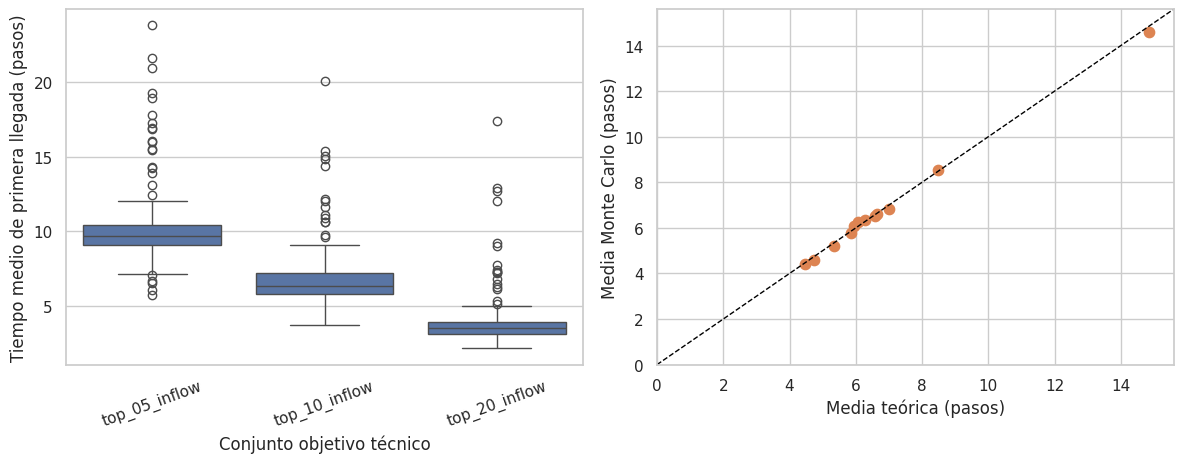

In [8]:
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

plot_fpt = fpt_by_origin.loc[~fpt_by_origin["is_target"]].copy()
sns.boxplot(
    data=plot_fpt,
    x="target_set",
    y="mean_fpt_steps",
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_xlabel("Conjunto objetivo técnico")
axes[0].set_ylabel("Tiempo medio de primera llegada (pasos)")
axes[0].tick_params(axis="x", rotation=20)

limit = float(simulation_validation[[
    "theoretical_mean_steps", "monte_carlo_mean_steps"
]].to_numpy().max()) * 1.05
axes[1].scatter(
    simulation_validation["theoretical_mean_steps"],
    simulation_validation["monte_carlo_mean_steps"],
    color="#DD8452",
    s=55,
)
axes[1].plot([0, limit], [0, limit], linestyle="--", color="black", linewidth=1)
axes[1].set_xlim(0, limit)
axes[1].set_ylim(0, limit)
axes[1].set_xlabel("Media teórica (pasos)")
axes[1].set_ylabel("Media Monte Carlo (pasos)")

fig.tight_layout()
fig.savefig(OUT / "fpt_numerical_validation.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Compuerta 5

Los criterios se fijan antes de introducir servicios o comparar grupos. La compuerta exige una cadena válida, buen condicionamiento y concordancia entre cálculo exacto y simulación.


In [9]:
thresholds = {
    "max_row_sum_error": 1e-10,
    "max_stationary_residual_l1": 1e-10,
    "min_spectral_gap": 0.01,
    "max_condition_number": 1e6,
    "max_median_mc_relative_error": 0.08,
    "max_p90_mc_relative_error": 0.15,
}

checks = {
    "gate4_dependency_valid": bool(
        gate4_status.get("gate_4_passed", False)
        and str(gate4_status.get(
            "recommended_resolution", gate4.get("recommended_resolution", "")
        )).upper() == "UTAM"
    ),
    "row_stochastic_valid": bool(
        row_sum_error <= thresholds["max_row_sum_error"]
    ),
    "irreducible_valid": irreducible,
    "aperiodic_valid": aperiodic,
    "stationary_solution_valid": bool(
        converged
        and stationary_residual <= thresholds["max_stationary_residual_l1"]
    ),
    "spectral_gap_valid": bool(
        spectral_gap >= thresholds["min_spectral_gap"]
    ),
    "finite_fpt_valid": bool(
        np.isfinite(fpt_by_origin["mean_fpt_steps"]).all()
        and (fpt_by_origin["mean_fpt_steps"] >= 0).all()
    ),
    "conditioning_valid": bool(
        fpt_summary["condition_number"].max()
        <= thresholds["max_condition_number"]
    ),
    "simulation_median_valid": bool(
        simulation_validation["relative_error"].median()
        <= thresholds["max_median_mc_relative_error"]
    ),
    "simulation_p90_valid": bool(
        simulation_validation["relative_error"].quantile(0.90)
        <= thresholds["max_p90_mc_relative_error"]
    ),
    "simulation_uncensored_valid": bool(
        simulation_validation["censored_walks"].sum() == 0
    ),
}
checks["gate_5_passed"] = bool(all(checks.values()))

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": int(RANDOM_SEED),
    "target_sets_are_technical_only": True,
    "fpt_unit": "transitions",
    "thresholds": {key: float(value) for key, value in thresholds.items()},
    "input_audit": input_audit,
    "chain_diagnostics": chain_diagnostics,
    "fpt_summary": json.loads(fpt_summary.to_json(orient="records")),
    "simulation_summary": {
        "origins": int(len(simulation_validation)),
        "replicates_per_origin": int(MC_REPLICATES),
        "median_relative_error": float(
            simulation_validation["relative_error"].median()
        ),
        "p90_relative_error": float(
            simulation_validation["relative_error"].quantile(0.90)
        ),
        "censored_walks": int(simulation_validation["censored_walks"].sum()),
    },
    "gate": checks,
}
(OUT / "gate_5.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
pd.Series(checks, name="result").to_csv(OUT / "gate_5_checks.csv")
display(pd.Series(checks, name="result"))

persistent_out = DRIVE_BASE / "results/gate5"
persistent_out.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent_out / artifact.name)

print("Compuerta 5:", "APROBADA" if checks["gate_5_passed"] else "NO APROBADA")
print("Copia persistente:", persistent_out)


,result
gate4_dependency_valid,True
row_stochastic_valid,True
irreducible_valid,True
aperiodic_valid,True
stationary_solution_valid,True
spectral_gap_valid,True
finite_fpt_valid,True
conditioning_valid,True
simulation_median_valid,True
simulation_p90_valid,True


Compuerta 5: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate5


## Interpretación y siguiente decisión

- Si la Compuerta 5 pasa, el álgebra de primer paso es estable sobre la red UTAM y puede avanzarse a objetivos sustantivos.
- Los valores de este notebook **no son todavía indicadores de acceso a servicios**: los objetivos por flujo entrante son controles técnicos.
- El siguiente notebook deberá construir conjuntos de destino preespecificados para trabajo, educación y salud, conservar la unidad en transiciones y, por separado, incorporar duración para una interpretación temporal.
- Las comparaciones por sexo y estrato deberán regularizarse hacia el kernel poblacional y reportar incertidumbre; no se seleccionarán segmentos según el tamaño del efecto observado.
